# 132 genomas de un cementerio neolítico. Una misma tumba, dos pueblos distintos.

**Paper:** Tallman, S. et al. "Population discontinuity in the Paris Basin linked to evidence of the Neolithic decline." *Nature Ecology & Evolution* (2026).
**DOI:** [10.1038/s41559-026-03027-z](https://doi.org/10.1038/s41559-026-03027-z)
**Datos:** [Supplementary Tables (Nature)](https://www.nature.com/articles/s41559-026-03027-z#Sec30)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-07-discontinuidad-paris-neolitico/notebook.ipynb)

## El contexto

Hace unos 5.000 años, algo cambió en Europa occidental. Los megalitos dejaron de construirse, los asentamientos se abandonaron y los bosques volvieron a crecer donde antes había campos de cultivo. Los arqueólogos lo llaman el *declive neolítico*.

En Escandinavia ya sabemos qué pasó: pueblos de las estepas reemplazaron a los agricultores. Pero en Francia, la historia era un misterio. Para resolverlo, un equipo secuenció 132 genomas antiguos de la *allée sépulcrale* de Bury, una tumba colectiva a 60 km de París que cubre DOS fases de entierro separadas por un hiato de ~300 años sin actividad funeraria.

Lo que encontraron detalla un recambio poblacional al final del Neolítico en Europa occidental — y la respuesta NO es la que esperábamos.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
HIATO_INICIO = -3107       # Último entierro Fase 1 (cal BC mediana)
HIATO_FIN = -2791          # Primer entierro Fase 2 (cal BC mediana)
SR_LOCAL_MAX = 0.7100      # Umbral Sr para posible origen no local
FUENTE = 'Fuente: Tallman et al. (2026), Nature Ecology & Evolution | Datos: Supplementary Tables'
COLOR_FASE1 = '#2563EB'    # Azul CaM — Fase 1 (pre-declive)
COLOR_FASE2 = '#DC2626'    # Rojo — Fase 2 (post-declive)
COLOR_REF = '#D97706'      # Amber — referencia
COLOR_SEC = '#059669'      # Emerald — datos secundarios

# ══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import os, urllib.request

# Estilo CaM
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Cargar datos
ind = pd.read_csv('datos/individuos.csv')
anc = pd.read_csv('datos/ancestria_distal.csv')
dates = pd.read_csv('datos/dataciones.csv')
dis = pd.read_csv('datos/enfermedades.csv')
sr = pd.read_csv('datos/estroncio.csv')

# Convertir tipos
ind['avg_age_cal_bc'] = pd.to_numeric(ind['avg_age_cal_bc'], errors='coerce')
# Convertir fase a string para consistencia
for df in [ind, anc, dates, dis, sr]:
    if 'phase' in df.columns:
        df['phase'] = df['phase'].astype(str)

# Resumen
print(f"Individuos: {len(ind)} ({len(ind[ind['phase']=='1'])} Fase 1, {len(ind[ind['phase']=='2'])} Fase 2)")
print(f"Ancestría: {len(anc)} muestras con modelo distal")
print(f"Dataciones: {len(dates)} (C14 calibrado)")
print(f"Patógenos: {dis['pathogen'].nunique()} especies en {dis['sample_id'].nunique()} individuos")
print(f"Estroncio: {len(sr)} mediciones")

Individuos: 178 (106 Fase 1, 62 Fase 2)
Ancestría: 80 muestras con modelo distal
Dataciones: 18 (C14 calibrado)
Patógenos: 40 especies en 71 individuos
Estroncio: 190 mediciones


## La misma tumba, dos identidades genéticas

Aquí está.

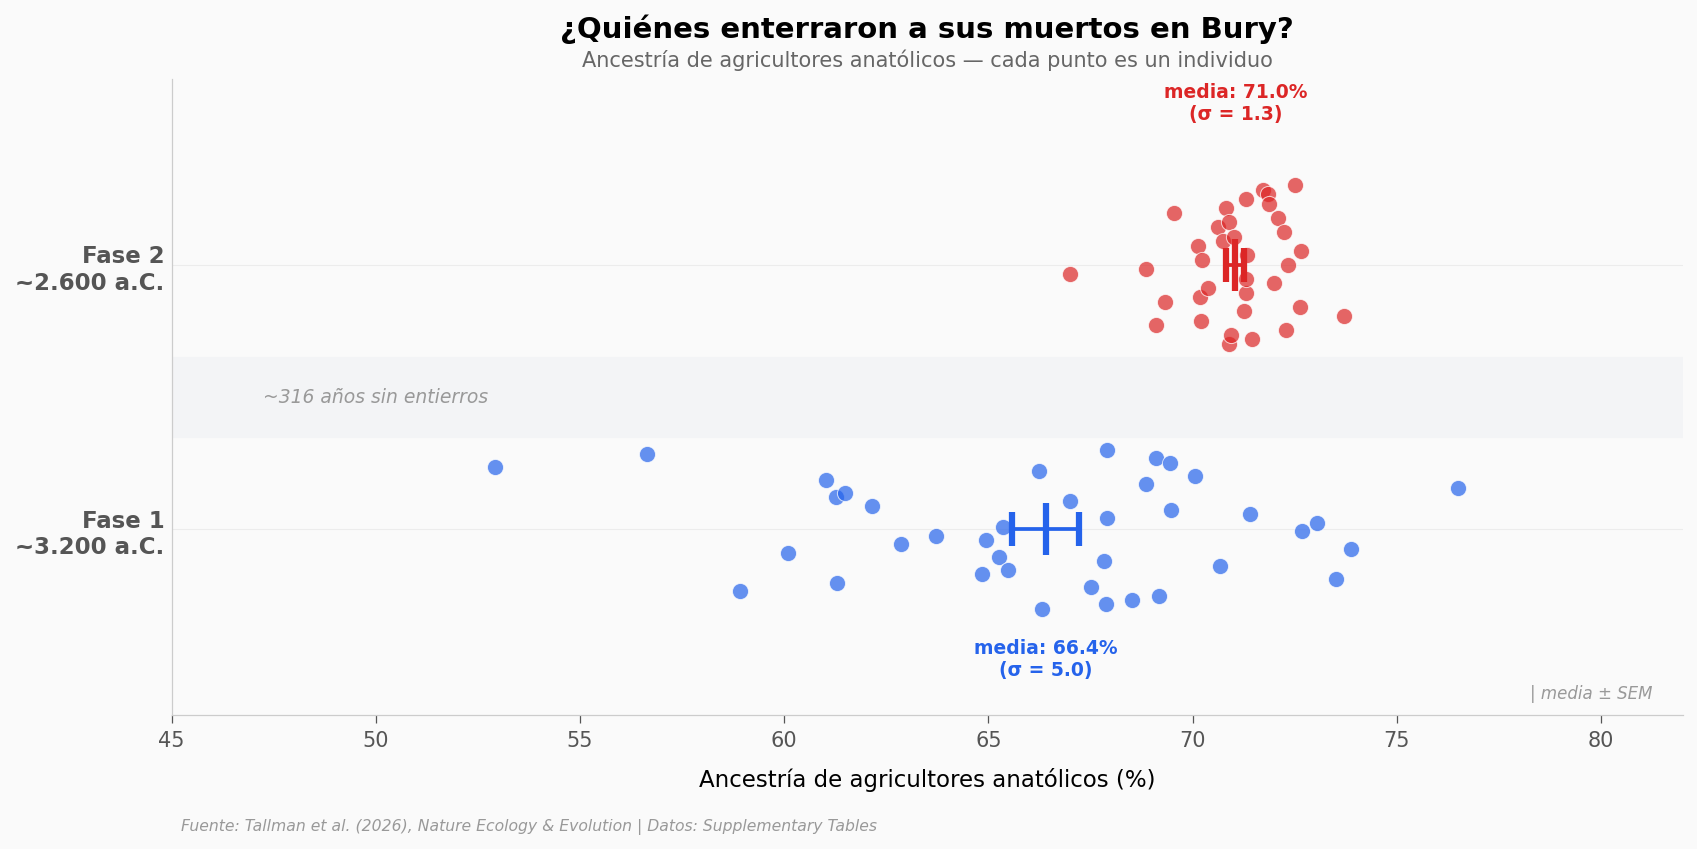

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Datos de ancestría por fase
a1 = anc[anc['phase'] == '1']['anatolian_farmers'].sort_values()
a2 = anc[anc['phase'] == '2']['anatolian_farmers'].sort_values()

# Fase 1: scatter con jitter vertical
np.random.seed(42)
y1 = np.linspace(0.7, 1.3, len(a1))
np.random.shuffle(y1)
ax.scatter(a1 * 100, y1, color=COLOR_FASE1, s=60, alpha=0.7,
           edgecolors='white', linewidths=0.5, zorder=5, label=f'Fase 1 (n={len(a1)})')

# Fase 2: scatter con jitter vertical
y2 = np.linspace(1.7, 2.3, len(a2))
np.random.shuffle(y2)
ax.scatter(a2 * 100, y2, color=COLOR_FASE2, s=60, alpha=0.7,
           edgecolors='white', linewidths=0.5, zorder=5, label=f'Fase 2 (n={len(a2)})')

# Medias + SEM
for vals, ypos, color, label in [(a1*100, 1.0, COLOR_FASE1, 'Fase 1'),
                                  (a2*100, 2.0, COLOR_FASE2, 'Fase 2')]:
    mean = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(len(vals))
    ax.errorbar(mean, ypos, xerr=sem, fmt='|', color=color,
                markersize=25, markeredgewidth=3, capsize=8, capthick=2, zorder=6)

# Zona del hiato
ax.axhspan(1.35, 1.65, color='#F3F4F6', zorder=0)
ax.text(50, 1.5, '~316 años sin entierros', fontsize=9, color='#999999',
        ha='center', va='center', style='italic')

# Etiquetas
ax.set_yticks([1.0, 2.0])
ax.set_yticklabels(['Fase 1\n~3.200 a.C.', 'Fase 2\n~2.600 a.C.'], fontsize=11, fontweight='bold')
ax.set_xlabel('Ancestría de agricultores anatólicos (%)', fontsize=11)
ax.set_xlim(45, 82)
ax.set_ylim(0.3, 2.7)

# Anotaciones inline
ax.text(a1.mean()*100, 0.45, f'media: {a1.mean()*100:.1f}%\n(σ = {a1.std()*100:.1f})', fontsize=9,
        color=COLOR_FASE1, ha='center', fontweight='bold')
ax.text(a2.mean()*100, 2.55, f'media: {a2.mean()*100:.1f}%\n(σ = {a2.std()*100:.1f})', fontsize=9,
        color=COLOR_FASE2, ha='center', fontweight='bold')

ax.set_title('¿Quiénes enterraron a sus muertos en Bury?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Ancestría de agricultores anatólicos — cada punto es un individuo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.text(0.98, 0.02, '| media ± SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/ancestria_por_fase.png', dpi=200, bbox_inches='tight')
plt.show()

La diferencia salta a la vista. La Fase 1 (~3.200 a.C.) muestra una comunidad genéticamente diversa: la ancestría de agricultores anatólicos varía entre 52,9% y 76,5% (σ = 5,0 puntos porcentuales). Algunos individuos tenían casi la mitad de su genoma de cazadores-recolectores europeos.

La Fase 2 (~2.600 a.C.) es radicalmente distinta: un grupo genéticamente homogéneo (σ = 1,3 pp) con más ancestría agrícola (media 71,0% vs 66,4%). La diferencia es estadísticamente robusta (Mann-Whitney p = 1,7 × 10⁻⁶) y el tamaño del efecto es grande (Cohen's d = 1,25).

Pero lo más revelador no es que tengan MÁS ancestría agrícola — es que son TAN uniformes. Pasaron de un grupo mezclado a uno casi clonal. Algo barrió la diversidad genética entre ambas fases.

## El hiato: 300 años de silencio

¿Cuándo dejaron de enterrar en Bury — y cuándo volvieron?

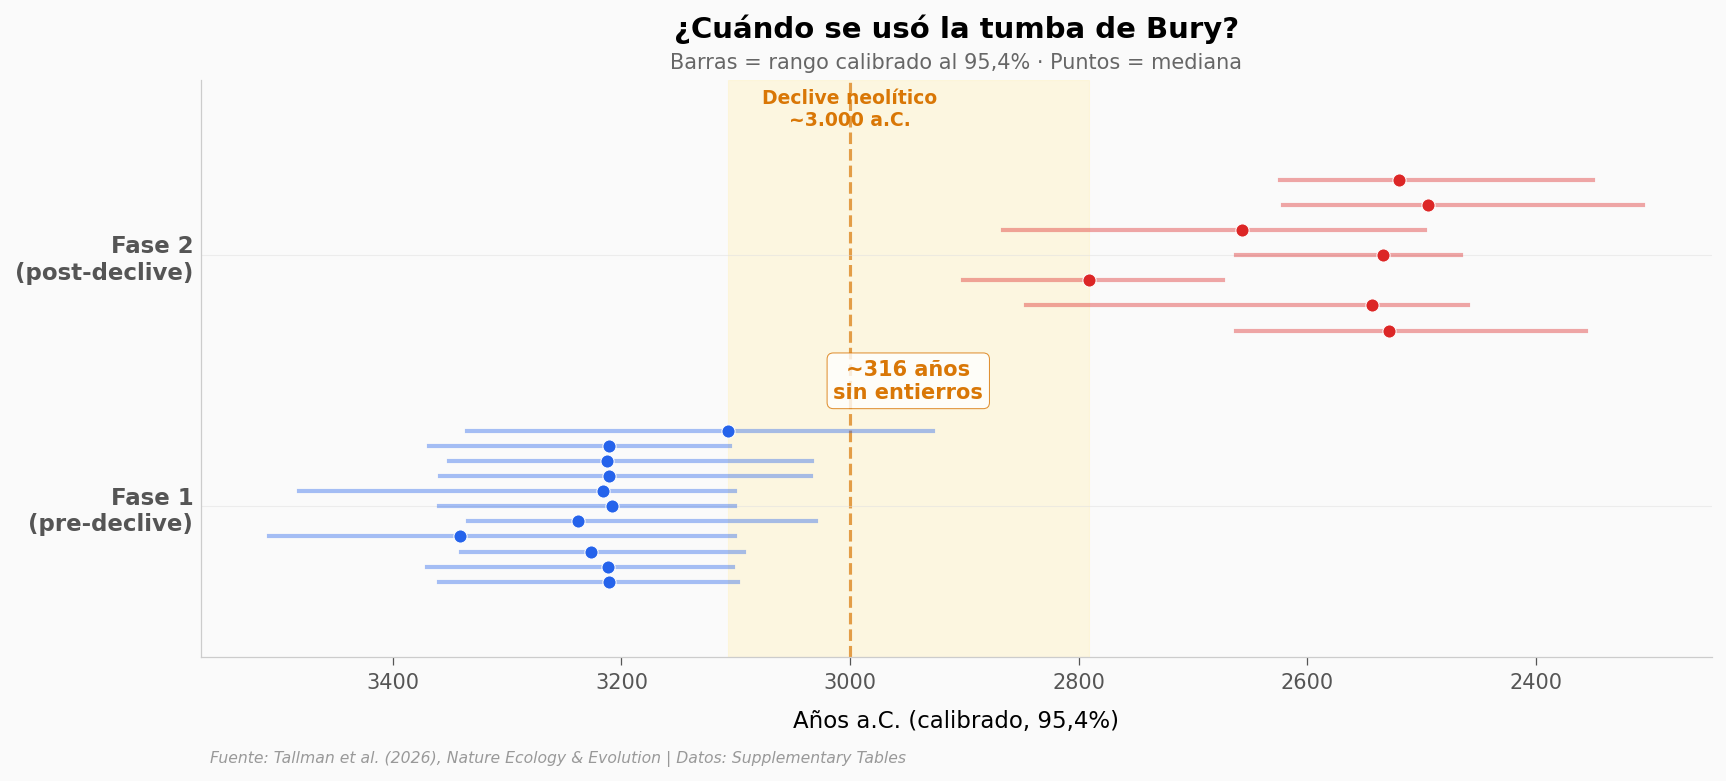

In [3]:
fig, ax = plt.subplots(figsize=(13, 5))

# Dataciones por fase
for phase, color, ybase in [('1', COLOR_FASE1, 1.0), ('2', COLOR_FASE2, 2.0)]:
    d = dates[dates['phase'] == phase].copy()
    d['cal_from_pos'] = -d['cal_bc_from_95']
    d['cal_to_pos'] = -d['cal_bc_to_95']
    d['cal_med_pos'] = -d['cal_bc_median']

    np.random.seed(42 + int(phase))
    y_jitter = np.linspace(ybase - 0.3, ybase + 0.3, len(d))
    np.random.shuffle(y_jitter)

    for i, (_, row) in enumerate(d.iterrows()):
        ax.plot([row['cal_from_pos'], row['cal_to_pos']], [y_jitter[i], y_jitter[i]],
                color=color, alpha=0.4, linewidth=2, zorder=3)
        ax.scatter(row['cal_med_pos'], y_jitter[i], color=color, s=40,
                   edgecolors='white', linewidths=0.5, zorder=5)

# Hiato
ax.axvspan(HIATO_INICIO * -1, HIATO_FIN * -1, color='#FEF3C7', alpha=0.5, zorder=0)
ax.text(((-HIATO_INICIO) + (-HIATO_FIN)) / 2, 1.5, '~316 años\nsin entierros',
        fontsize=10, color=COLOR_REF, ha='center', va='center', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=COLOR_REF, alpha=0.8))

# Línea de referencia: ~3000 BC = "Neolithic decline"
ax.axvline(x=3000, color=COLOR_REF, linewidth=1.5, linestyle='--', alpha=0.7, zorder=1)
ax.text(3000, 2.5, 'Declive neolítico\n~3.000 a.C.', fontsize=9, color=COLOR_REF,
        ha='center', va='bottom', fontweight='bold')

ax.set_yticks([1.0, 2.0])
ax.set_yticklabels(['Fase 1\n(pre-declive)', 'Fase 2\n(post-declive)'],
                    fontsize=11, fontweight='bold')
ax.set_xlabel('Años a.C. (calibrado, 95,4%)', fontsize=11)
ax.set_ylim(0.4, 2.7)
ax.invert_xaxis()

ax.set_title('¿Cuándo se usó la tumba de Bury?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Barras = rango calibrado al 95,4% · Puntos = mediana',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/dataciones_timeline.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿De dónde venían?

¿Los enterrados en Bury crecieron todos cerca de París? El estroncio (⁸⁷Sr/⁸⁶Sr) en los dientes lo delata — si no coincide con la roca local, viniste de otro sitio.

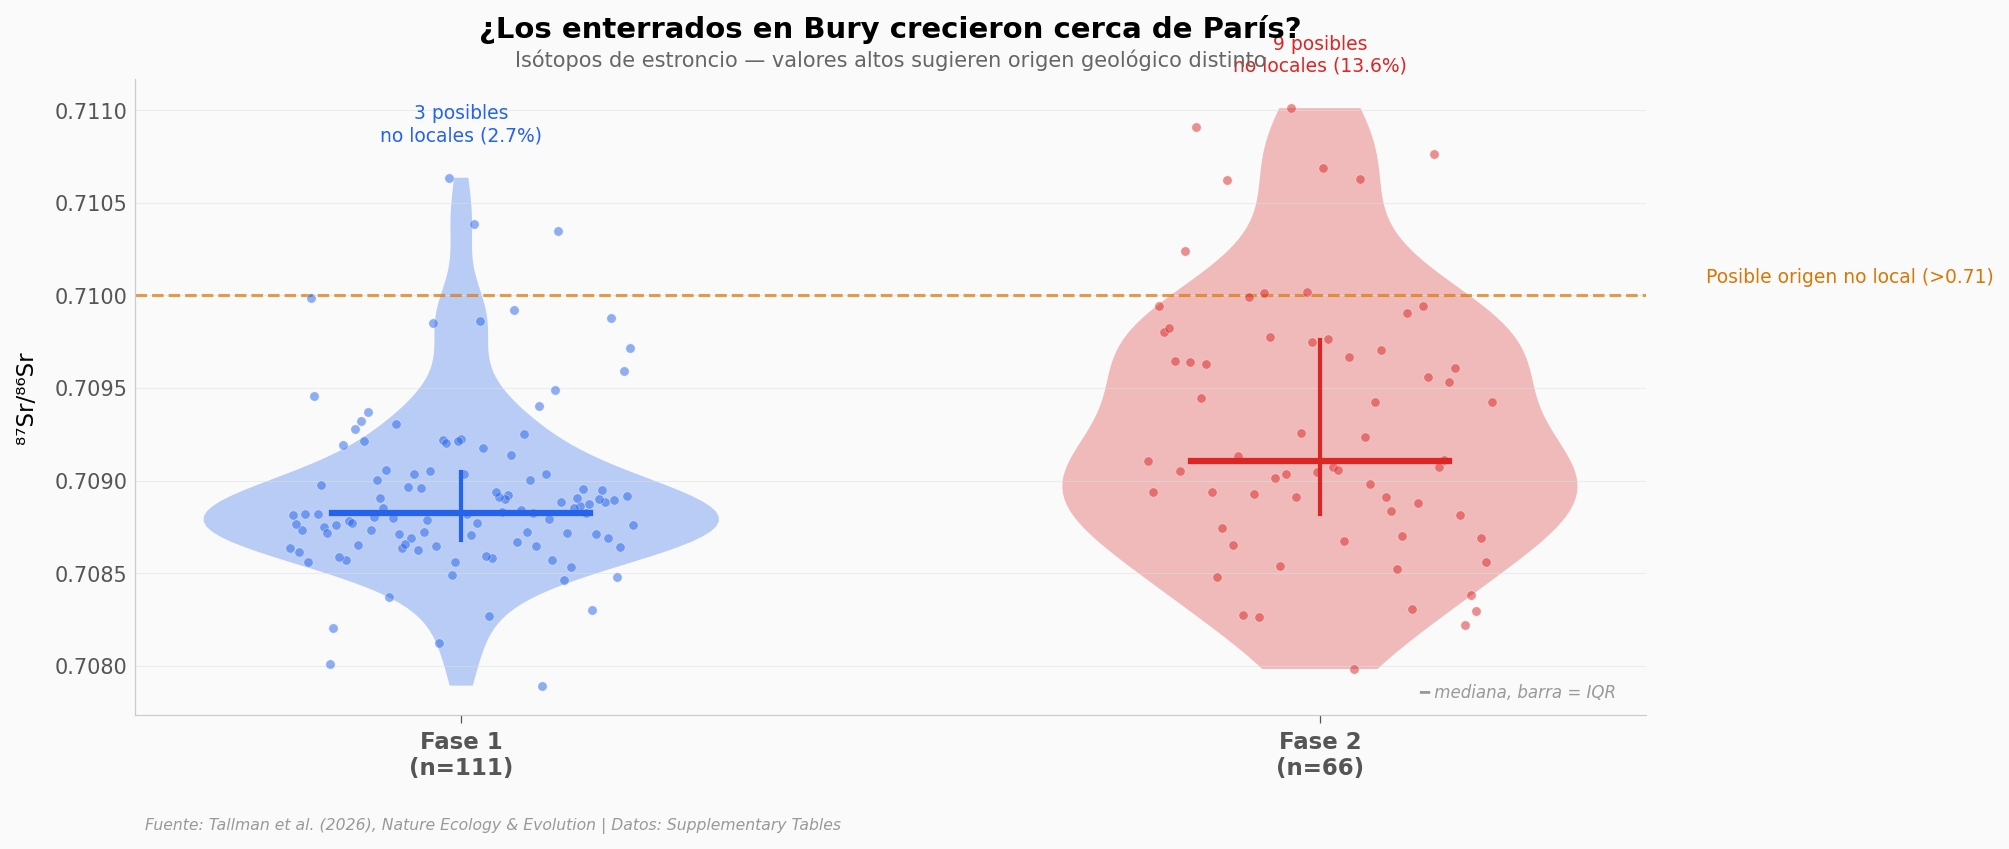

In [4]:
fig, ax = plt.subplots(figsize=(13, 5.5))

sr1 = sr[sr['phase'] == '1']['sr_87_86']
sr2 = sr[sr['phase'] == '2']['sr_87_86']

# Violins
parts1 = ax.violinplot([sr1], positions=[1], showmeans=False, showextrema=False, widths=0.6)
parts2 = ax.violinplot([sr2], positions=[2], showmeans=False, showextrema=False, widths=0.6)
for pc in parts1['bodies']:
    pc.set_facecolor(COLOR_FASE1)
    pc.set_alpha(0.3)
for pc in parts2['bodies']:
    pc.set_facecolor(COLOR_FASE2)
    pc.set_alpha(0.3)

# Scatter con jitter
np.random.seed(42)
x1 = np.linspace(0.8, 1.2, len(sr1))
np.random.shuffle(x1)
x2 = np.linspace(1.8, 2.2, len(sr2))
np.random.shuffle(x2)

ax.scatter(x1, sr1, color=COLOR_FASE1, s=20, alpha=0.5, edgecolors='white', linewidths=0.3, zorder=5)
ax.scatter(x2, sr2, color=COLOR_FASE2, s=20, alpha=0.5, edgecolors='white', linewidths=0.3, zorder=5)

# Mediana + IQR
for vals, pos, color in [(sr1, 1.0, COLOR_FASE1), (sr2, 2.0, COLOR_FASE2)]:
    med = vals.median()
    q25, q75 = vals.quantile(0.25), vals.quantile(0.75)
    ax.plot([pos-0.15, pos+0.15], [med, med], color=color, linewidth=3, zorder=6)
    ax.plot([pos, pos], [q25, q75], color=color, linewidth=2, zorder=6)

# Umbral no local
ax.axhline(y=SR_LOCAL_MAX, color=COLOR_REF, linewidth=1.5, linestyle='--', alpha=0.7)
ax.text(2.45, SR_LOCAL_MAX + 0.00005, f'Posible origen no local (>{SR_LOCAL_MAX})',
        fontsize=9, color=COLOR_REF, va='bottom')

ax.set_xticks([1, 2])
ax.set_xticklabels(['Fase 1\n(n=111)', 'Fase 2\n(n=66)'], fontsize=11, fontweight='bold')
ax.set_ylabel('⁸⁷Sr/⁸⁶Sr', fontsize=11)

# Contar outliers
out1 = (sr1 > SR_LOCAL_MAX).sum()
out2 = (sr2 > SR_LOCAL_MAX).sum()
ax.text(1, sr1.max() + 0.0002, f'{out1} posibles\nno locales ({out1/len(sr1)*100:.1f}%)',
        fontsize=9, color=COLOR_FASE1, ha='center')
ax.text(2, sr2.max() + 0.0002, f'{out2} posibles\nno locales ({out2/len(sr2)*100:.1f}%)',
        fontsize=9, color=COLOR_FASE2, ha='center')

ax.set_title('¿Los enterrados en Bury crecieron cerca de París?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Isótopos de estroncio — valores altos sugieren origen geológico distinto',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.text(0.98, 0.02, '━ mediana, barra = IQR', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/estroncio_por_fase.png', dpi=200, bbox_inches='tight')
plt.show()

La Fase 2 tiene 5 veces más proporción de posibles individuos no locales: 13,6% (9 de 66) frente a 2,7% (3 de 111) en la Fase 1. La distribución de estroncio es más dispersa (σ = 0,00071, n = 66 vs σ = 0,00045, n = 111), y la diferencia entre fases es significativa (Mann-Whitney p = 0,0002, d = 0,66 — efecto medio).

Los nuevos ocupantes de Bury no solo eran genéticamente distintos — también venían de lugares más variados.

## Y luego está la peste

Cuatro individuos tenían ADN de *Yersinia pestis* — la bacteria de la peste bubónica. Peste en el Neolítico, 4.000 años antes de la Muerte Negra.

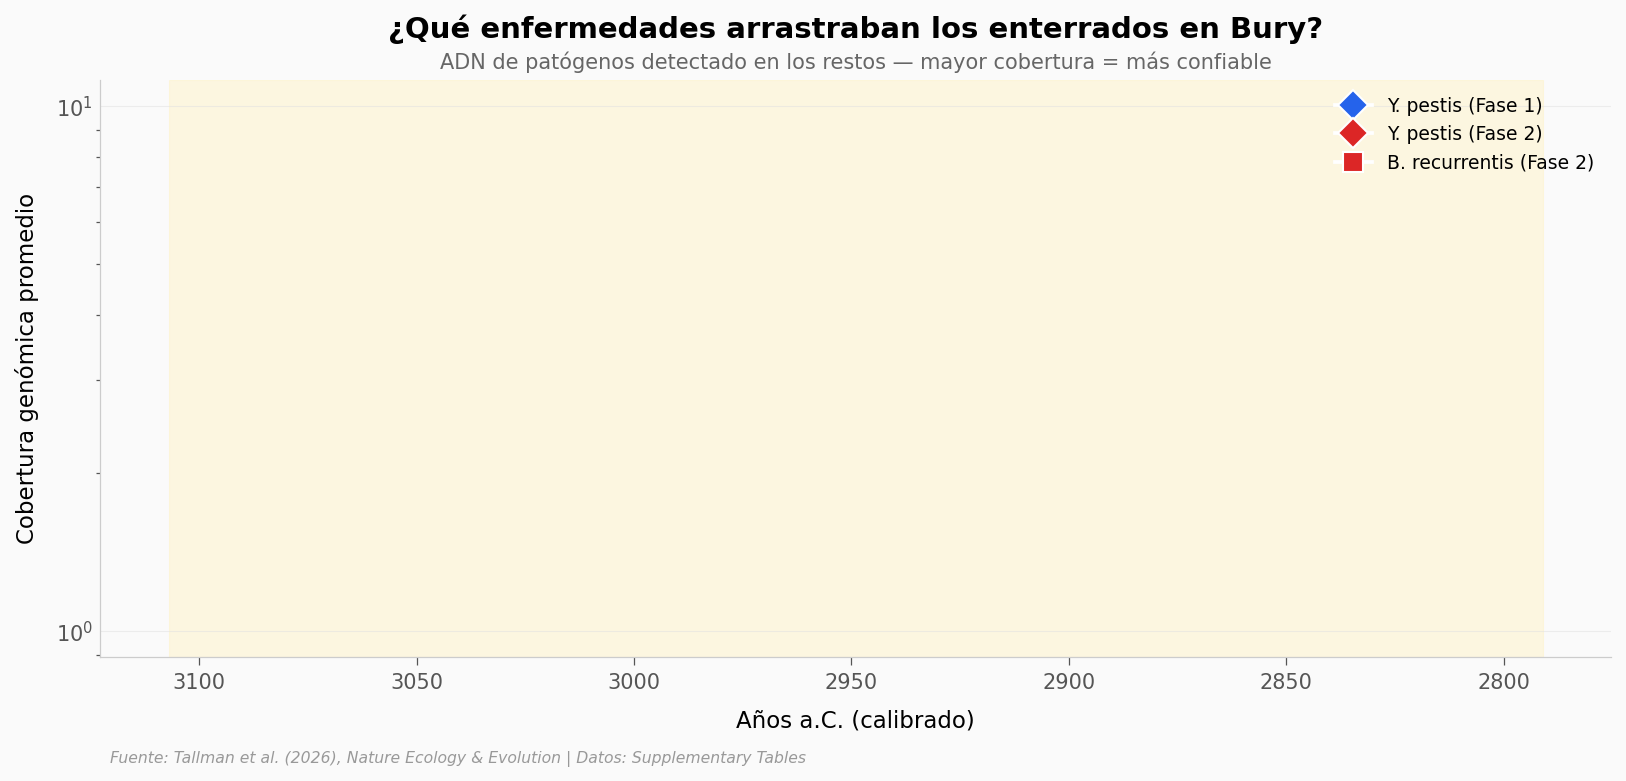

In [5]:
fig, ax = plt.subplots(figsize=(13, 5))

# Patógenos clave
key_pathogens = ['Yersinia pestis', 'Borrelia recurrentis']
key_dis = dis[dis['pathogen'].isin(key_pathogens)].copy()
key_dis = key_dis.merge(ind[['sample_id', 'avg_age_cal_bc']], on='sample_id', how='left')

# Colores por fase
colors = {'1': COLOR_FASE1, '2': COLOR_FASE2}
markers = {'Yersinia pestis': 'D', 'Borrelia recurrentis': 's'}

for _, row in key_dis.iterrows():
    phase = row['phase']
    color = colors.get(phase, '#BBBBBB')
    marker = markers.get(row['pathogen'], 'o')
    age = -row['avg_age_cal_bc'] if pd.notna(row['avg_age_cal_bc']) else None

    if age:
        ax.scatter(age, row['coverage_avg'], color=color, s=120, marker=marker,
                   edgecolors='white', linewidths=1, zorder=5, alpha=0.85)
        label = row['sample_id'].replace('BUR', '')
        ax.annotate(f"BUR{label}\n{row['pathogen'].split()[0][0]}. {row['pathogen'].split()[1][:4]}.",
                    (age, row['coverage_avg']),
                    textcoords="offset points", xytext=(12, 5),
                    fontsize=8, color=color)

# Hiato
ax.axvspan(-HIATO_INICIO, -HIATO_FIN, color='#FEF3C7', alpha=0.5, zorder=0)

# Leyenda manual
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='D', color='w', markerfacecolor=COLOR_FASE1, markersize=10, label='Y. pestis (Fase 1)'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor=COLOR_FASE2, markersize=10, label='Y. pestis (Fase 2)'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor=COLOR_FASE2, markersize=10, label='B. recurrentis (Fase 2)'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='upper right', framealpha=0.9)

ax.set_xlabel('Años a.C. (calibrado)', fontsize=11)
ax.set_ylabel('Cobertura genómica promedio', fontsize=11)
ax.invert_xaxis()
ax.set_yscale('log')

ax.set_title('¿Qué enfermedades arrastraban los enterrados en Bury?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'ADN de patógenos detectado en los restos — mayor cobertura = más confiable',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/enfermedades_timeline.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Qué tan distinta era la nueva población?

Veamos la distribución completa — porque el promedio solo cuenta la mitad de la historia.

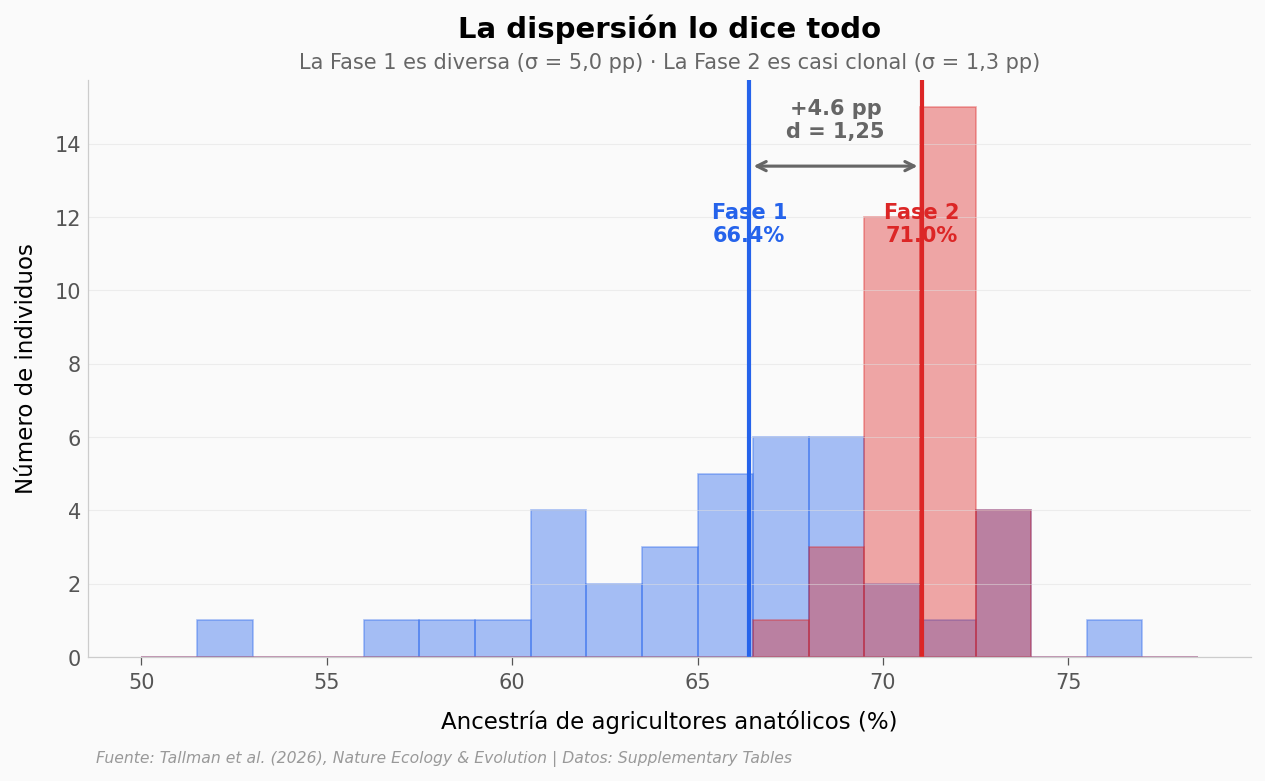

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

# Histograma de ancestría farmer para ambas fases
bins = np.arange(50, 80, 1.5)

ax.hist(anc[anc['phase'] == '1']['anatolian_farmers'] * 100, bins=bins,
        color=COLOR_FASE1, alpha=0.4, edgecolor=COLOR_FASE1, linewidth=0.8, label='Fase 1')
ax.hist(anc[anc['phase'] == '2']['anatolian_farmers'] * 100, bins=bins,
        color=COLOR_FASE2, alpha=0.4, edgecolor=COLOR_FASE2, linewidth=0.8, label='Fase 2')

# Medias
mean1 = anc[anc['phase'] == '1']['anatolian_farmers'].mean() * 100
mean2 = anc[anc['phase'] == '2']['anatolian_farmers'].mean() * 100
y_max = ax.get_ylim()[1]

ax.axvline(x=mean1, color=COLOR_FASE1, linewidth=2, linestyle='-')
ax.axvline(x=mean2, color=COLOR_FASE2, linewidth=2, linestyle='-')

# Flecha bidireccional
arrow_y = y_max * 0.85
ax.annotate('', xy=(mean2, arrow_y), xytext=(mean1, arrow_y),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((mean1 + mean2) / 2, arrow_y + y_max * 0.05,
        f'+{mean2 - mean1:.1f} pp\nd = 1,25',
        fontsize=10, color='#666666', ha='center', fontweight='bold')

# Labels
ax.text(mean1, y_max * 0.72, f'Fase 1\n{mean1:.1f}%', fontsize=10,
        color=COLOR_FASE1, ha='center', fontweight='bold')
ax.text(mean2, y_max * 0.72, f'Fase 2\n{mean2:.1f}%', fontsize=10,
        color=COLOR_FASE2, ha='center', fontweight='bold')

ax.set_xlabel('Ancestría de agricultores anatólicos (%)', fontsize=11)
ax.set_ylabel('Número de individuos', fontsize=11)
ax.set_title('La dispersión lo dice todo',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'La Fase 1 es diversa (σ = 5,0 pp) · La Fase 2 es casi clonal (σ = 1,3 pp)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_ancestria.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Las dos fases de entierro representan grupos genéticos distintos | ✅ | Ancestría farmer: 66,4% vs 71,0% (d = 1,25, p = 1,7 × 10⁻⁶). La varianza cambia drásticamente (Levene p = 1,9 × 10⁻⁶) |
| La Fase 2 es genéticamente más homogénea | ✅ | σ Fase 1 = 5,0 pp vs σ Fase 2 = 1,3 pp — ~3,9 veces menos variación |
| Hay un hiato de ~300 años sin entierros | ✅ | Última datación Fase 1 (mediana): ~3.107 a.C. Primera Fase 2: ~2.791 a.C. → ~316 años |
| Se detectó *Yersinia pestis* en individuos de ambas fases | ✅ | 4 individuos: BUR212, BUR218, BUR345 (Fase 1) y BUR184 (Fase 2). BUR218 tiene la mayor cobertura (0,218) |
| La Fase 2 tiene más individuos con Sr no local | ✅ | 13,6% (9/66) vs 2,7% (3/111) — 5× más proporción de posibles no locales |
| El cambio se explica por un movimiento de ancestría desde el sur | ⚠️ | Los datos muestran MÁS ancestría farmer en Fase 2 y mayor homogeneidad, lo cual es consistente con la hipótesis. Pero el dataset cubre UN solo sitio — la dirección geográfica (sur → norte) requiere comparación con otros yacimientos |

> **Limitaciones:** (1) Los 80 individuos con modelo de ancestría son un subconjunto de los 178 — requieren cobertura genómica suficiente. (2) Las dataciones (n=18) son pocas para definir los límites exactos del hiato. (3) El umbral de estroncio (0,710) es aproximado — la señal local del sustrato calcáreo de la Cuenca de París varía. (4) La detección de patógenos depende de la cobertura: individuos con baja cobertura genómica pueden tener falsos negativos.

## Ahora tú

1. **¿Qué familias dominaron cada fase?** El pedigrí más grande de la Fase 1 tiene 29 miembros (pedigree_1.A) y es mayoritariamente masculino (21 XY, 8 XX). El de la Fase 2 tiene 10 miembros, todos XY. ¿Qué implica esto sobre la organización social? Prueba filtrar `ind[ind['family_id'] == 'pedigree_1.A']` y comparar haplogrupos.

2. **¿Hay correlación entre estroncio y ancestría?** Si los no locales vienen de más lejos, ¿su ancestría farmer difiere de los locales? Cruza `sr` con `anc` por `sample_id` y haz un scatter.

3. **¿Cuándo apareció la peste en Europa?** Las cepas de Bury (~3.200 a.C.) son anteriores a las grandes epidemias medievales por 4.000 años. ¿Era la misma cepa? El paper encuentra evidencia de transmisión por piojos (*Borrelia recurrentis*) en la Fase 2 — ¿coincide con el aumento de movilidad (Sr)?

In [7]:
# --- EXPERIMENTA AQUÍ ---
# ¿Qué haplogrupos Y dominan en cada fase?
# Los haplogrupos del cromosoma Y se heredan por línea paterna.
# Un cambio de haplogrupos entre fases = diferentes linajes masculinos.

phase1_y = ind[(ind['phase'] == '1') & (ind['y_haplogroup'].notna()) & (ind['y_haplogroup'] != '')]['y_haplogroup']
phase2_y = ind[(ind['phase'] == '2') & (ind['y_haplogroup'].notna()) & (ind['y_haplogroup'] != '')]['y_haplogroup']

# Agrupar por haplogrupo mayor (primera letra + primer dígito)
def major_hg(hg):
    if pd.isna(hg) or hg == '':
        return 'Sin datos'
    # Tomar hasta el primer nivel (ej: I2a1a1 → I2)
    parts = str(hg)
    if len(parts) >= 2:
        return parts[:2]
    return parts

print("══ Haplogrupos Y por fase ══")
print(f"\nFase 1 (n={len(phase1_y)}):")
for hg, n in phase1_y.apply(major_hg).value_counts().items():
    print(f"  {hg}: {n} ({n/len(phase1_y)*100:.0f}%)")

print(f"\nFase 2 (n={len(phase2_y)}):")
for hg, n in phase2_y.apply(major_hg).value_counts().items():
    print(f"  {hg}: {n} ({n/len(phase2_y)*100:.0f}%)")

print("\n¿Ves algún haplogrupo que desaparezca o aparezca entre fases?")

══ Haplogrupos Y por fase ══

Fase 1 (n=47):
  H2: 28 (60%)
  I2: 19 (40%)

Fase 2 (n=35):
  I2: 34 (97%)
  G2: 1 (3%)

¿Ves algún haplogrupo que desaparezca o aparezca entre fases?


---

**Paper:** Tallman, S. et al. "Population discontinuity in the Paris Basin linked to evidence of the Neolithic decline." *Nature Ecology & Evolution* (2026). DOI: [10.1038/s41559-026-03027-z](https://doi.org/10.1038/s41559-026-03027-z)

**Datos:** Supplementary Tables 1-13 (Nature) — [descargar](https://www.nature.com/articles/s41559-026-03027-z#Sec30)

**Genomas:** European Nucleotide Archive, accesión [PRJEB95770](https://www.ebi.ac.uk/ena/browser/view/PRJEB95770)

**Licencia datos:** CC BY 4.0 (como parte de artículo Nature OA)

**Notebook:** [Ciencia a Mordiscos — El Lab](https://github.com/Ciencia-a-Mordiscos/lab)